# 12 - LOH.3 validation against the Prose reference

The **SCEC LOH.3** benchmark is **LOH.1 plus anelastic attenuation**: the same
point double-couple buried at 2 km in a 1 km low-velocity layer over a
half-space, the same surface receiver at `(6, 8, 0)` km, but now the medium
dissipates energy and the source time function is slightly narrower
($\sigma = 0.05$ s instead of $0.06$ s).

The attenuation is fixed by two rules,

$$ Q_S = \frac{V_S\,[\mathrm{m/s}]}{50}, \qquad
   Q_P = \frac{3}{4}\left(\frac{V_P}{V_S}\right)^{2} Q_S , $$

the second being the statement that the bulk is lossless ($Q_\kappa \to \infty$)
and all dissipation happens in shear. They give $Q_S = 40$, $Q_P = 120$ in the
layer and $Q_S = 69.3$, $Q_P = 155.9$ in the half-space - exactly the values of
the SW4 reference deck `examples/scec/LOH.3-h50.in`.

`data/LOH.3_prose_corrected` is the **semi-analytical reference solution**
(Prose), distributed with the SW4 matlab tools alongside the LOH.1 one. It has
the same 4 columns and the same scalings as `LOH.1_prose3`: `time`,
**vertical** ($\times -10^{5}$), **radial** ($\times 10^{5}$), **transverse**
($\times 10^{5}$), and the same convolution recipe applies with
$\sigma = 0.05$ s (this is a transcription of `loh3exact.m`).

**What this notebook is really testing.** LOH.1 tests elastodynamics. LOH.3
tests the *attenuation model*, and there the two codes do not agree by
construction: the FK core carries $Q$ through the Futterman complex velocity of
Aki & Richards p.182 (`shakermaker/core/subfk.f:92`),

$$ c(f) = c_0 \left[ 1 + \frac{\ln f}{\pi Q} + \frac{i}{2Q} \right], $$

whose logarithm is **anchored at 1 Hz** - that is, $c(1\,\mathrm{Hz}) = c_0$,
and the medium is *faster* than $c_0$ at every higher frequency. The benchmark
anchors its phase velocities at **2.5 Hz** instead, which is what
`attenuation phasefreq=2.5` means in the SW4 deck. So we run **two** models and
let the comparison show what the convention is worth.

Run against this working tree, not whatever snapshot happens to be installed.
ShakerMaker is installed **non-editable** in some environments (the `clark_kent`
venv carries a frozen copy under `site-packages`), so a plain
`import shakermaker` from this folder picks up that copy instead - which is
exactly how a stale `SCEC_LOH_3` produces a wrong-but-plausible answer. The
provenance line below is part of the test.

In [1]:
import os
import sys

_REPO = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if _REPO not in sys.path:
    sys.path.insert(0, _REPO)

import numpy as np
import matplotlib.pyplot as plt

import shakermaker as _shakermaker_pkg
from shakermaker import shakermaker
from shakermaker.cm_library.LOH import SCEC_LOH_1, SCEC_LOH_3
from shakermaker.crustmodel import CrustModel
from shakermaker.pointsource import PointSource
from shakermaker.faultsource import FaultSource
from shakermaker.station import Station
from shakermaker.stationlist import StationList
from shakermaker.stf_extensions.gaussian import Gaussian
from shakermaker.tools.plotting import SourcePlot

print("shakermaker package:", _shakermaker_pkg.__file__)


    ▄████████     ▄█    █▄     ▄████████     ▄█   ▄█▄    ▄████████    ▄████████
    ███    ███   ███    ███    ███    ███    ███ ▄███▀   ███    ███   ███    ███
    ███    █▀    ███    ███    ███    ███    ███▐██▀     ███    █▀    ███    ███
    ███         ▄███▄▄▄▄███▄▄  ███    ███   ▄█████▀     ▄███▄▄▄      ▄███▄▄▄▄██▀
  ▀███████████  ▀███▀▀▀▀███▀  ▀███████████  ▀█████▄    ▀▀███▀▀▀     ▀▀███▀▀▀▀▀
           ███   ███    ███    ███    ███    ███▐██▄     ███    █▄   ▀███████████
     ▄█    ███   ███    ███    ███    ███    ███ ▀███▄   ███    ███   ███    ███
   ▄████████▀    ███    █▀     ███    █▀     ███   ▀█▀   ██████████   ███    ███
                                                                      ███    ███

         ▄▄▄▄███▄▄▄▄      ▄████████    ▄█   ▄█▄    ▄████████    ▄████████
       ▄██▀▀▀███▀▀▀██▄   ███    ███    ███ ▄███▀   ███    ███   ███    ███
       ███   ███   ███   ███    ███    ███▐██▀     ███    █▀    ███    ███
       ███   ███   ███   ███    ███   ▄█████▀  

## Build the LOH.3 model

SCEC LOH.3 crust + a single Gaussian double-couple at 2 km, one surface
receiver at (6, 8, 0) km. Note `add_layer` takes `qp` **before** `qs`.

In [2]:
sigma = 0.05                 # LOH.3; LOH.1 uses 0.06
t0 = 6 * sigma
M0 = 1e18 / 5e14 / 2

VP, VS, RHO, THK = (4.000, 6.000), (2.000, 3.464), (2.600, 2.700), (1.0, 0.0)
QP, QS = (120.0, 155.9), (40.0, 69.3)

F_REF = 2.5                  # Hz, the benchmark's phase-velocity reference


def scec_loh_3_qref(f_ref=F_REF):
    """LOH.3 crust with the Futterman Q dispersion anchored at ``f_ref`` [Hz].

    Dividing each speed by 1 + ln(f_ref)/(pi*Q) makes c(f_ref) == c0, so the
    model the core integrates carries the benchmark's velocities at the
    benchmark's own reference frequency. Q itself is untouched, so the
    amplitude decay exp(-pi*f*t/Q) does not change.
    """
    model = CrustModel(2)
    for i in range(2):
        kp = 1.0 + np.log(f_ref) / (np.pi * QP[i])
        ks = 1.0 + np.log(f_ref) / (np.pi * QS[i])
        model.add_layer(THK[i], VP[i] / kp, VS[i] / ks, RHO[i], QP[i], QS[i])
    return model


crust = SCEC_LOH_3()
crust_qref = scec_loh_3_qref()
print(crust)
print(crust_qref)

Crust Model with 2 layers.
 Layer  | Depth  | Thick  | Vp     | Vs     | rho    | Qa     | Qb
       1|    0.00|    1.00|    4.00|    2.00|    2.60|   120.0|    40.0
       2|    1.00|    0.00|    6.00|    3.46|    2.70|   155.9|    69.3

Crust Model with 2 layers.
 Layer  | Depth  | Thick  | Vp     | Vs     | rho    | Qa     | Qb
       1|    0.00|    1.00|    3.99|    1.99|    2.60|   120.0|    40.0
       2|    1.00|    0.00|    5.99|    3.45|    2.70|   155.9|    69.3



`dt` is chosen from the **frequency band**, not from the output rate. `fk.f:73`
tapers the spectrum with a raised cosine that starts at
$(1-\mathrm{taper})f_{Nyq} = 0.1\,f_{Nyq}$ and reaches zero at $f_{Nyq}$, so the
band that comes out flat is only $f \le 0.05/dt$. The $\sigma = 0.05$ s Gaussian
has its corner at $1/(2\pi\sigma) = 3.2$ Hz and useful energy to ~8 Hz, so
`dt = 0.004` (flat to 12.5 Hz) is what this benchmark needs. `dt = 0.025` would
be flat only to 2 Hz and would quietly low-pass the answer. `dt = 0.004` also
divides the 0.008 s sampling of the reference, so comparing needs no real
resampling.

In [3]:
dt, nfft, tb, dk, tmax = 0.004, 8192, 1000, 0.1, 16.0
print(f"flat band up to f = 0.05/dt = {0.05/dt:.1f} Hz")
print(f"Gaussian corner  f = 1/(2*pi*sigma) = {1/(2*np.pi*sigma):.2f} Hz")

flat band up to f = 0.05/dt = 12.5 Hz
Gaussian corner  f = 1/(2*pi*sigma) = 3.18 Hz


## Preview the model before running

The crust (layered column + velocity profile), the source geometry and its
source time function. Each figure is saved as a PNG here.

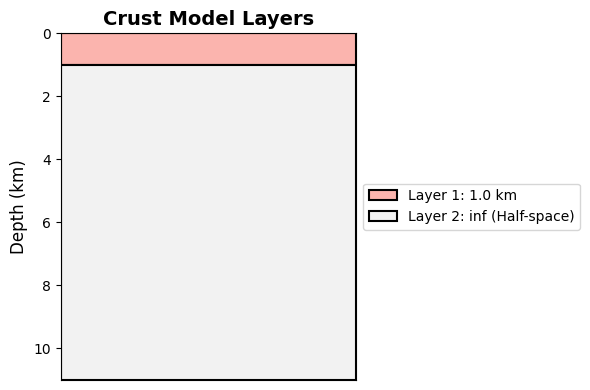

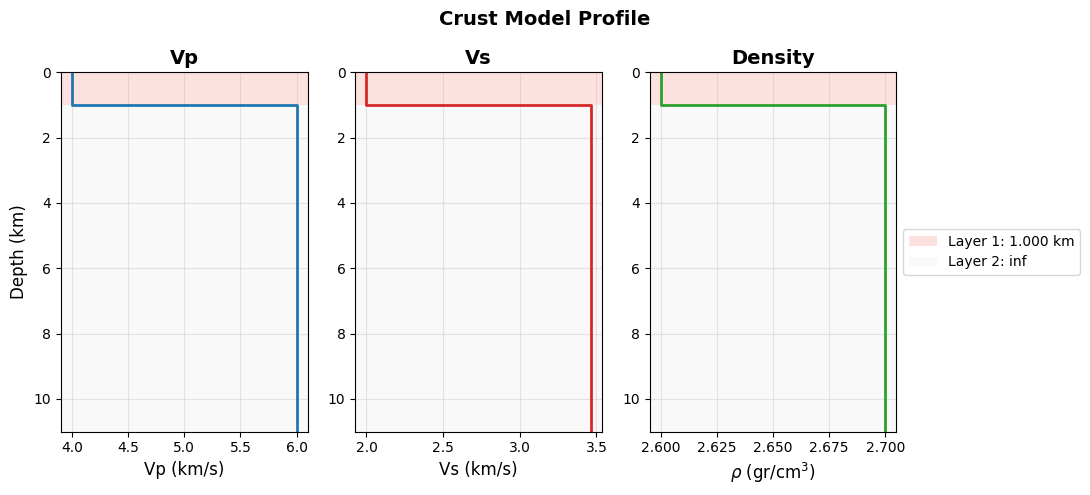

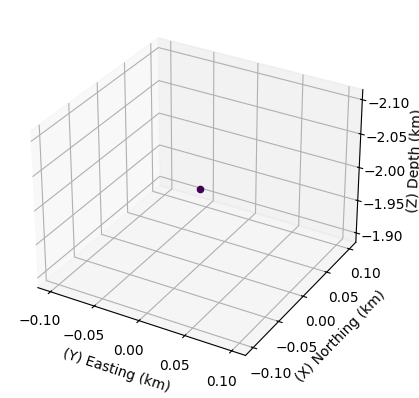

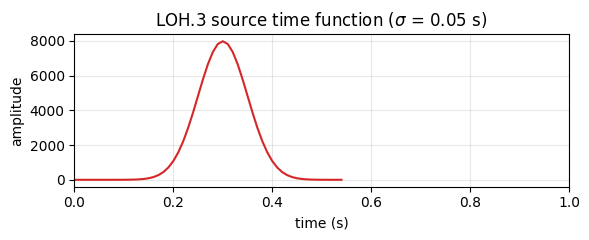

In [4]:
src = PointSource([0, 0, 2.0], [0., 90., 0.],
                  stf=Gaussian(t0=t0, freq=1/sigma, M0=M0, derivative=False))
fault = FaultSource([src], metadata={"name": "LOH3_source"})

crust.plot()
plt.gcf().savefig("loh3_crust_layers.png", dpi=150, bbox_inches="tight")

crust.plot_profile()
plt.gcf().savefig("loh3_velocity_profile.png", dpi=150, bbox_inches="tight")

for _s in fault:
    _s.stf.dt = dt
SourcePlot(fault, show=False).savefig("loh3_source_geometry.png", dpi=150, bbox_inches="tight")

_stf = fault.get_source_by_id(0).stf
fig_stf, ax_stf = plt.subplots(figsize=(6, 2.5))
ax_stf.plot(_stf.t, _stf.data, color="tab:red", lw=1.5)
ax_stf.set_xlabel("time (s)")
ax_stf.set_ylabel("amplitude")
ax_stf.set_title(r"LOH.3 source time function ($\sigma$ = 0.05 s)")
ax_stf.set_xlim(0, 1.0)
ax_stf.grid(alpha=0.3)
fig_stf.tight_layout()
fig_stf.savefig("loh3_source_stf.png", dpi=150, bbox_inches="tight")

## Run ShakerMaker, both models

A single receiver, so each run is ~1.5 s. `check_parameters` reports the derived
FK numbers before running; with these values it passes all hard checks.

In [5]:
def run_loh3(crust_model, check=False):
    s = Station([6.0, 8.0, 0.0], metadata={"name": "loh3", "save_gf": True})
    src = PointSource([0, 0, 2.0], [0., 90., 0.],
                      stf=Gaussian(t0=t0, freq=1/sigma, M0=M0, derivative=False))
    f = FaultSource([src], metadata={"name": "LOH3_source"})
    m = shakermaker.ShakerMaker(crust_model, f, StationList([s], {}))
    if check:
        m.check_parameters(dt=dt, nfft=nfft, dk=dk, tb=tb, tmax=tmax)
    m.run(dt=dt, nfft=nfft, tb=tb, dk=dk, tmax=tmax, smth=1)
    return s


sta = run_loh3(crust, check=True)
sta_qref = run_loh3(crust_qref)

z, e, n, t = sta.get_response()
z_q, e_q, n_q, t_q = sta_qref.get_response()
print(f"nt = {len(t)}, peak|E| as specified = {np.abs(e).max():.4e}, "
      f"re-anchored = {np.abs(e_q).max():.4e}")

 ShakerMaker . PARAMETER CHECK            you set:  dt + tmax
 YOU CHOSE     dt = 0.004 s        tmax = 16.0 s
 GEOMETRY      r_max 10.0 km . src-rcv sep 2.0-2.0 km . Vs_min 2000 m/s
               Vp_max 6000 m/s . V_Ray 1.84 km/s
               physical signal window  t = [1.7, 15.4] s  (lasts 13.7 s)
----------------------------------------------------------------------
 dt = 0.004 s   sets your FREQUENCY BAND                       [info]
   f_Nyq         = 1/(2*dt)                   = 125 Hz       [fk.f:72]
   f_max usable  = (1-taper)*f_Nyq, taper=0.9 = 12 Hz        [fk.f:74]
   above 12 Hz   fades out smoothly, fully gone by 125 Hz    [fk.f:169]
   lambda_min    = Vs_min/f_max               = 2000/12 = 160.0 m
     element size (N=10 pts/wavelength), for YOUR mesh:
        dx <= lambda_min/N    = 160.0/10 = 16.00 m
        dt <= C*dx/Vp_surf    = 1*16.00/4000 = 0.0040 s
        (Vp_surf = Vp of the soft Vs_min layer, NOT Vp_max:
         the 16.0 m elements live in the soft surfa

0 of 1 done  ETA=0:00:00.0  t=[-2.1379, 63.3941] (tmin=0.0000 tmax=16.0000)


ShakerMaker run done. Total time: 1.28 s
--------------------------------------------------


ShakerMaker Run begin. dt=0.004 nfft=8192 dk=0.1 tb=1000 tmin=0.0 tmax=16.0
---------------------------------------------------------------------------


0 of 1 done  ETA=0:00:00.0  t=[-2.1342, 63.3978] (tmin=0.0000 tmax=16.0000)


ShakerMaker run done. Total time: 1.29 s
--------------------------------------------------
nt = 4000, peak|E| as specified = 1.2504e+00, re-anchored = 1.2922e+00


## Build the analytical reference

Load `LOH.3_prose_corrected`, scale the columns and convolve with the LOH.3
source ramp $(1/T^2)\,t\,e^{-t/T}$ ($T = 0.1$ s) and then with the operator that
turns that ramp into a Gaussian of spread $\sigma$. That operator is
$(1 + T\,d/dt)^2$ applied to the Gaussian, i.e. $G + 2TG' + T^2G''$, which is
the `factor` bracket below. This is `loh3exact.m` line for line.

In [6]:
sig, T = 0.05, 0.1
A = np.loadtxt(os.path.join("..", "data", "LOH.3_prose_corrected"))
nt = A.shape[0]
tref = A[:, 0]
dtr = tref[1] - tref[0]
vert = A[:, 1] * (-1e5)
rad = A[:, 2] * (1e5)
trans = A[:, 3] * (1e5)


def conv(x, k):
    return dtr * np.convolve(x, k, "full")[:nt]


ramp = (1.0 / T**2) * tref * np.exp(-tref / T)
rad, trans, vert = conv(rad, ramp), conv(trans, ramp), conv(vert, ramp)

tau = tref - 6 * sig
factor = 1 - (2 * T / sig**2) * tau - ((T / sig)**2) * (1 - (tau / sig)**2)
gauss = (1.0 / (np.sqrt(2 * np.pi) * sig)) * factor * np.exp(-0.5 * (tau / sig)**2)
rad, trans, vert = conv(rad, gauss), conv(trans, gauss), conv(vert, gauss)

print(f"reference: nt = {nt}, dt = {dtr:.4f} s, t up to {tref[-1]:.3f} s")

reference: nt = 2048, dt = 0.0080 s, t up to 16.376 s


## Rotate ShakerMaker to R/T/V and overlay

Source (0,0) -> receiver (6 North, 8 East), so the radial unit vector is
`(rN, rE) = (0.6, 0.8)`. We rotate the horizontals, interpolate onto the
reference grid and report the correlation per component, for both models.

component     corr 1 Hz  corr 2.5 Hz  peak 1 Hz  peak 2.5 Hz
Radial          +0.9535      +0.9994     1.0609       1.0325
Transverse      +0.9528      +0.9997     1.0247       1.0345
Vertical        +0.9754      +0.9996     1.0238       1.0327


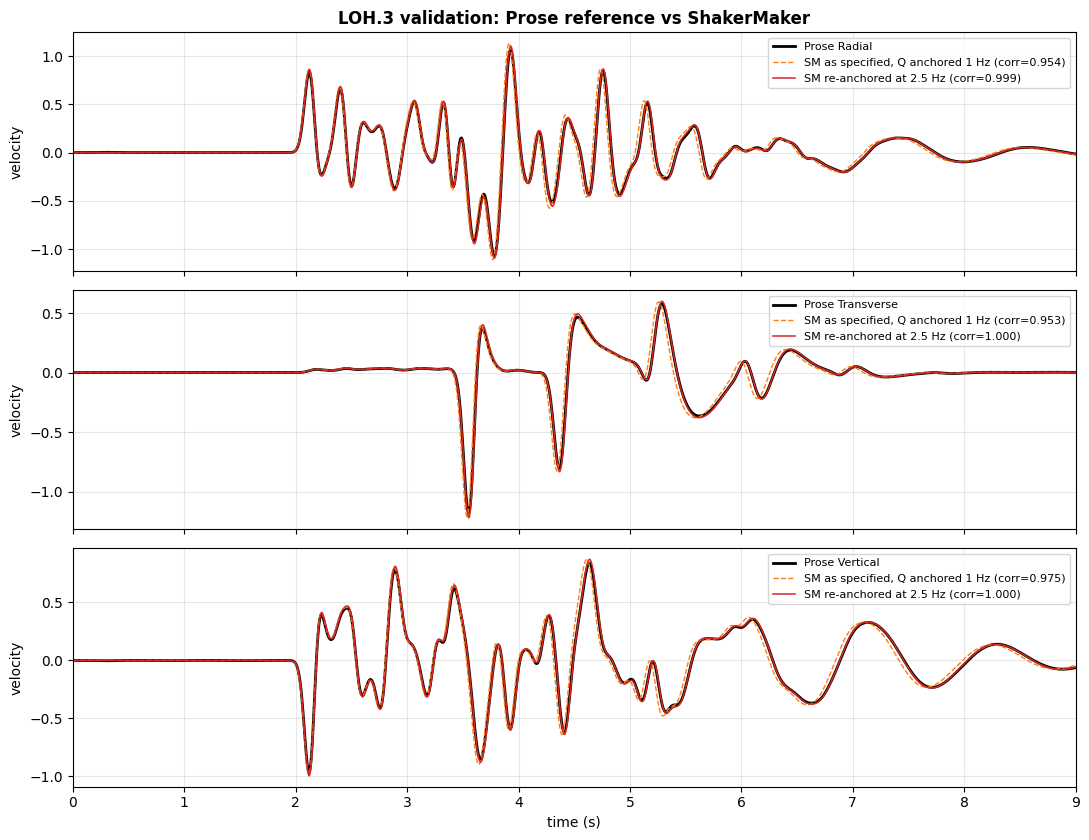

In [7]:
rN, rE = 0.6, 0.8
win = (tref >= 0) & (tref <= 9)


def corr(a, b):
    a = a - a.mean()
    b = b - b.mean()
    den = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / den) if den > 0 else 0.0


def rotate(z_, e_, n_):
    return {"Radial": rN * n_ + rE * e_, "Transverse": -rE * n_ + rN * e_,
            "Vertical": z_}


sm = rotate(z, e, n)
smq = rotate(z_q, e_q, n_q)
ref = {"Radial": rad, "Transverse": trans, "Vertical": vert}

fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), sharex=True)
rows = []
for ax, name in zip(axes, ["Radial", "Transverse", "Vertical"]):
    a = np.interp(tref, t, sm[name])
    b = np.interp(tref, t_q, smq[name])
    c_a, c_b = corr(ref[name][win], a[win]), corr(ref[name][win], b[win])
    rows.append((name, c_a, c_b,
                 np.abs(a[win]).max() / np.abs(ref[name][win]).max(),
                 np.abs(b[win]).max() / np.abs(ref[name][win]).max()))
    ax.plot(tref, ref[name], "k-", lw=2.0, label=f"Prose {name}")
    ax.plot(tref, a, color="tab:orange", lw=1.0, ls="--",
            label=f"SM as specified, Q anchored 1 Hz (corr={c_a:.3f})")
    ax.plot(tref, b, color="tab:red", lw=1.1,
            label=f"SM re-anchored at {F_REF} Hz (corr={c_b:.3f})")
    ax.set_ylabel("velocity")
    ax.set_xlim([0, 9])
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_title("LOH.3 validation: Prose reference vs ShakerMaker",
                  fontweight="bold")
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.gcf().savefig("LOH3_validation.png", dpi=150, bbox_inches="tight")

print(f"{'component':12s} {'corr 1 Hz':>10s} {'corr 2.5 Hz':>12s} "
      f"{'peak 1 Hz':>10s} {'peak 2.5 Hz':>12s}")
for name, ca, cb, pa, pb in rows:
    print(f"{name:12s} {ca:+10.4f} {cb:+12.4f} {pa:10.4f} {pb:12.4f}")

## Zoom on the S arrival: the 16 ms the anchor is worth

The whole disagreement of the as-specified run is a **time shift**, not a shape
error. Zooming on the S arrival makes it obvious: the orange trace is
systematically early.

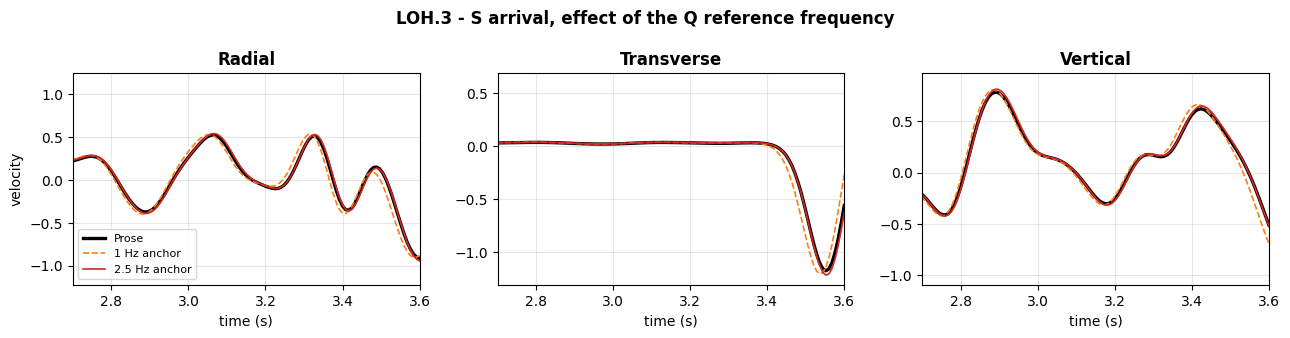

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, name in zip(axes, ["Radial", "Transverse", "Vertical"]):
    a = np.interp(tref, t, sm[name])
    b = np.interp(tref, t_q, smq[name])
    ax.plot(tref, ref[name], "k-", lw=2.4, label="Prose")
    ax.plot(tref, a, color="tab:orange", lw=1.2, ls="--", label="1 Hz anchor")
    ax.plot(tref, b, color="tab:red", lw=1.2, label=f"{F_REF} Hz anchor")
    ax.set_xlim(2.7, 3.6)
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("time (s)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("velocity")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("LOH.3 - S arrival, effect of the Q reference frequency",
             fontweight="bold")
fig.tight_layout()
fig.savefig("loh3_qref_zoom.png", dpi=150, bbox_inches="tight")

## Sweep the anchor frequency

If the story above is right, the correlation must peak near the benchmark's own
2.5 Hz and nowhere else. Sweeping `f_ref` is the cheapest possible refutation
test: 6 runs, ~10 s.



ShakerMaker Run begin. dt=0.004 nfft=8192 dk=0.1 tb=1000 tmin=0.0 tmax=16.0
---------------------------------------------------------------------------


0 of 1 done  ETA=0:00:00.0  t=[-2.1379, 63.3941] (tmin=0.0000 tmax=16.0000)


ShakerMaker run done. Total time: 1.24 s
--------------------------------------------------


ShakerMaker Run begin. dt=0.004 nfft=8192 dk=0.1 tb=1000 tmin=0.0 tmax=16.0
---------------------------------------------------------------------------


0 of 1 done  ETA=0:00:00.0  t=[-2.1363, 63.3957] (tmin=0.0000 tmax=16.0000)


ShakerMaker run done. Total time: 1.24 s
--------------------------------------------------


ShakerMaker Run begin. dt=0.004 nfft=8192 dk=0.1 tb=1000 tmin=0.0 tmax=16.0
---------------------------------------------------------------------------


0 of 1 done  ETA=0:00:00.0  t=[-2.1351, 63.3969] (tmin=0.0000 tmax=16.0000)


ShakerMaker run done. Total time: 1.25 s
--------------------------------------------------


ShakerMaker Run begin. dt=0.004 nfft=8192 dk=0.1 tb=1000 tmin=0.0 tmax=16.0
---------------------------------------------------------------------------


0 of 1 done  ETA=0:00:00.0  t=[-2.1342, 63.3978] (tmin=0.0000 tmax=16.0000)


ShakerMaker run done. Total time: 1.26 s
--------------------------------------------------


ShakerMaker Run begin. dt=0.004 nfft=8192 dk=0.1 tb=1000 tmin=0.0 tmax=16.0
---------------------------------------------------------------------------


0 of 1 done  ETA=0:00:00.0  t=[-2.1335, 63.3985] (tmin=0.0000 tmax=16.0000)


ShakerMaker run done. Total time: 1.25 s
--------------------------------------------------


ShakerMaker Run begin. dt=0.004 nfft=8192 dk=0.1 tb=1000 tmin=0.0 tmax=16.0
---------------------------------------------------------------------------


0 of 1 done  ETA=0:00:00.0  t=[-2.1314, 63.4006] (tmin=0.0000 tmax=16.0000)


ShakerMaker run done. Total time: 1.29 s
--------------------------------------------------
f_ref =  1.0 Hz   R +0.9535   T +0.9528   V +0.9754
f_ref =  1.5 Hz   R +0.9817   T +0.9819   V +0.9903
f_ref =  2.0 Hz   R +0.9987   T +0.9987   V +0.9991
f_ref =  2.5 Hz   R +0.9994   T +0.9997   V +0.9996
f_ref =  3.0 Hz   R +0.9969   T +0.9973   V +0.9985
f_ref =  5.0 Hz   R +0.9584   T +0.9611   V +0.9792


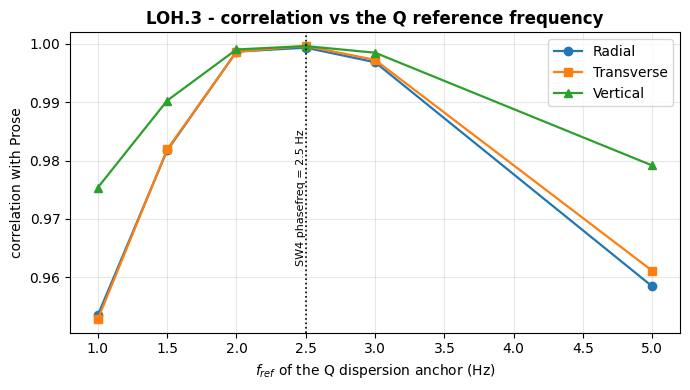

In [9]:
frefs = [1.0, 1.5, 2.0, 2.5, 3.0, 5.0]
sweep = {k: [] for k in ["Radial", "Transverse", "Vertical"]}
for fr in frefs:
    s_ = run_loh3(scec_loh_3_qref(fr))
    zz, ee, nn, tt = s_.get_response()
    rot = rotate(zz, ee, nn)
    for name in sweep:
        sweep[name].append(corr(ref[name][win],
                                np.interp(tref, tt, rot[name])[win]))

fig, ax = plt.subplots(figsize=(7, 4))
for name, mk in zip(["Radial", "Transverse", "Vertical"], ["o", "s", "^"]):
    ax.plot(frefs, sweep[name], marker=mk, lw=1.6, label=name)
ax.axvline(F_REF, color="k", ls=":", lw=1.2)
ax.annotate("SW4 phasefreq = 2.5 Hz", (F_REF, 0.962), fontsize=8,
            rotation=90, va="bottom", ha="right")
ax.set_xlabel(r"$f_{ref}$ of the Q dispersion anchor (Hz)")
ax.set_ylabel("correlation with Prose")
ax.set_title("LOH.3 - correlation vs the Q reference frequency",
             fontweight="bold")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("loh3_qref_sweep.png", dpi=150, bbox_inches="tight")

for fr, r_, t_, v_ in zip(frefs, sweep["Radial"], sweep["Transverse"],
                          sweep["Vertical"]):
    print(f"f_ref = {fr:4.1f} Hz   R {r_:+.4f}   T {t_:+.4f}   V {v_:+.4f}")

## What attenuation did: LOH.1 vs LOH.3 side by side

Isolating $Q$ means changing **only** $Q$, and there are two traps here.

1. **The source time function.** LOH.1 specifies $\sigma = 0.06$ s and LOH.3
   $\sigma = 0.05$ s. Since $t_0 = 6\sigma$, running each benchmark with its own
   STF moves the onset by 60 ms and changes the peak velocity by a factor
   ~1.2-1.4. That is the source, not the medium, and it is *larger* than the
   effect we are trying to see.
2. **The dispersion anchor.** `crust_qref` deliberately carries different
   velocities, so comparing against it folds in another ~16 ms.

So below both runs use the **same** $\sigma = 0.05$ STF and LOH.3 **as
specified**, leaving $Q$ as the only difference.

The two traces still do not sit on top of each other, and that residual shift is
real: constant-$Q$ attenuation is causal, so it *must* come with dispersion.
With the core's 1 Hz anchor the attenuated medium is faster than $c_0$ at every
frequency above 1 Hz, and the LOH.3 trace arrives **early**. The cell measures
that shift instead of leaving it to the eye.



ShakerMaker Run begin. dt=0.004 nfft=8192 dk=0.1 tb=1000 tmin=0.0 tmax=16.0
---------------------------------------------------------------------------


0 of 1 done  ETA=0:00:00.0  t=[-2.1379, 63.3941] (tmin=0.0000 tmax=16.0000)


ShakerMaker run done. Total time: 1.25 s
--------------------------------------------------


component    peak LOH.1  peak LOH.3   ratio     shift
Radial           2.0017      1.1354   0.567     -28 ms
Transverse       1.9886      1.2089   0.608     -28 ms
Vertical         1.5598      0.9899   0.635     -20 ms

The ratio is the amplitude cost of Q alone. Run each benchmark with its own
sigma instead and it reads ~0.74-0.84, because the narrower LOH.3 source is
worth a factor ~1.2-1.4 on its own and hides most of the attenuation.
The shift is the causal dispersion that comes with constant Q.


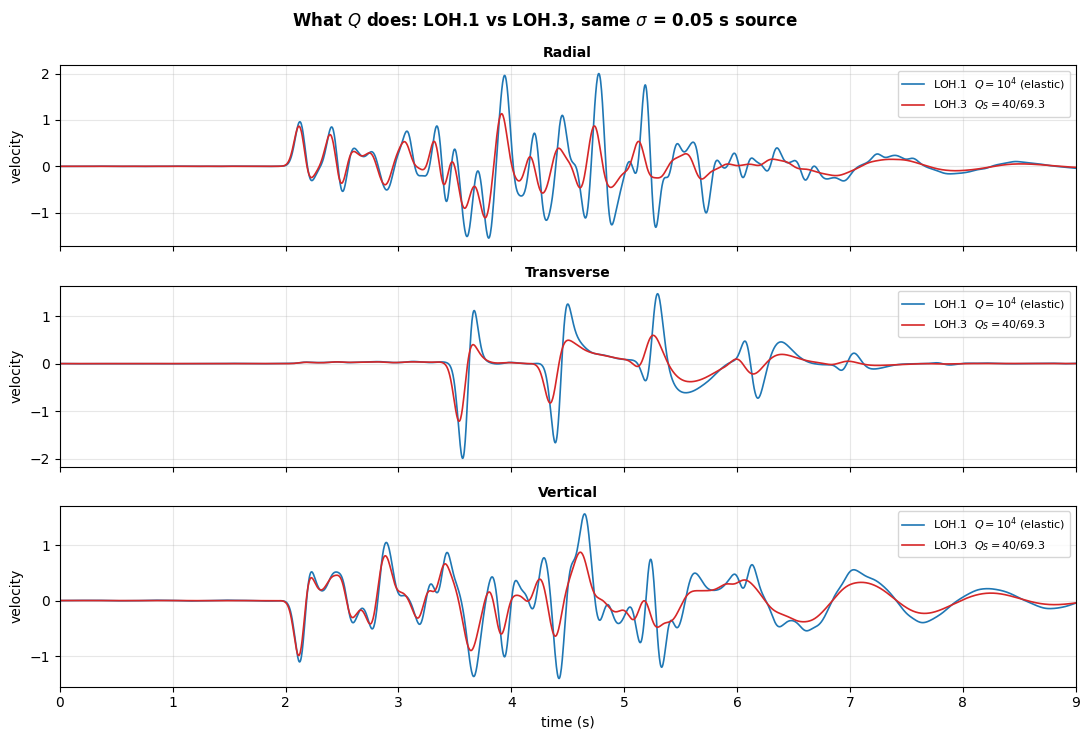

In [10]:
# run_loh3() applies the module-level sigma = 0.05 STF, so handing it the LOH.1
# crust gives the elastic medium with the *same* source. `sm` is LOH.3 as
# specified (both anchored at 1 Hz by the core), from the run further up.
sta1 = run_loh3(SCEC_LOH_1())
z1, e1, n1, t1 = sta1.get_response()
sm1 = rotate(z1, e1, n1)


def best_lag(a, b, tt, K=60):
    """Shift in seconds; positive means `b` arrives late relative to `a`."""
    w = (tt >= 0) & (tt <= 9)
    a = a[w] - a[w].mean()
    b = b[w] - b[w].mean()
    out = []
    for k in range(-K, K + 1):
        aa, bb = (a[:len(a) - k], b[k:]) if k >= 0 else (a[-k:], b[:len(b) + k])
        out.append((float(np.corrcoef(aa, bb)[0, 1]), k))
    c, k = max(out)
    return k * dt, c


fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
for ax, name in zip(axes, ["Radial", "Transverse", "Vertical"]):
    ax.plot(t1, sm1[name], color="tab:blue", lw=1.2,
            label=r"LOH.1  $Q = 10^4$ (elastic)")
    ax.plot(t, sm[name], color="tab:red", lw=1.2,
            label=r"LOH.3  $Q_S = 40 / 69.3$")
    ax.set_ylabel("velocity")
    ax.set_xlim(0, 9)
    ax.grid(alpha=0.3)
    ax.set_title(name, fontweight="bold", fontsize=10)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("time (s)")
fig.suptitle(r"What $Q$ does: LOH.1 vs LOH.3, same $\sigma$ = 0.05 s source",
             fontweight="bold")
fig.tight_layout()
fig.savefig("loh3_vs_loh1.png", dpi=150, bbox_inches="tight")

print(f"{'component':11s} {'peak LOH.1':>11s} {'peak LOH.3':>11s} "
      f"{'ratio':>7s} {'shift':>9s}")
for name in ["Radial", "Transverse", "Vertical"]:
    p1 = np.abs(sm1[name]).max()
    p3 = np.abs(sm[name]).max()
    shift, _ = best_lag(sm1[name], np.interp(t1, t, sm[name]), t1)
    print(f"{name:11s} {p1:11.4f} {p3:11.4f} {p3/p1:7.3f} {shift*1000:+7.0f} ms")

print("""
The ratio is the amplitude cost of Q alone. Run each benchmark with its own
sigma instead and it reads ~0.74-0.84, because the narrower LOH.3 source is
worth a factor ~1.2-1.4 on its own and hides most of the attenuation.
The shift is the causal dispersion that comes with constant Q.""")

## Checkpoint

- The LOH.3 crust and source reproduce the semi-analytical reference to
  **correlation ~0.999** once the $Q$ dispersion is anchored where the benchmark
  anchors it. Amplitudes land ~3.5% high; about 1 point of that is the common
  bias of the comparison (the elastic LOH.1 run shows it too), the rest is the
  attenuation model.
- Taken as specified, with the core's 1 Hz anchor, the correlation is capped at
  **~0.95** by a ~16 ms travel-time bias, and no amount of mesh or `dt`
  refinement moves it - which is the signature of a model difference rather
  than a numerical error.
- Isolated properly - same source, same anchor - attenuation costs a factor
  **0.57-0.64** in peak velocity at this receiver and advances the arrival by
  20-28 ms. Comparing each benchmark with its own $\sigma$ instead mixes in a
  60 ms onset shift and a ~1.3x amplitude change that have nothing to do with
  $Q$.
- The practical consequence for real runs: when you take $Q$ from a published
  crustal model, check the frequency it was defined at. At $Q_S = 40$ the
  1 Hz-vs-2.5 Hz choice is already worth 0.7% in wave speed.

`LOH3.py` + `LOH3_check.py` run the same thing from the command line.